# <center>Customer Churn Analysis</center>

## Project Overview

### Business Problem
The objective of this project is to analyze customer churn for a telecommunications company, identify the key factors associated with customer churn, and provide actionable insights that can help improve customer retention.

### Tools & Technologies
- Python
- Pandas
- MySQL
- Power BI
- CSV

## 1. Import Libraries

We import the Python libraries required for data analysis and visualization.

In [2]:
import pandas as pd

## 2. Load Dataset

The raw customer churn dataset is loaded into a Pandas DataFrame for analysis and data cleaning.

In [3]:
df = pd.read_csv(r"C:\Users\Admin\0. Python\Project\telco_churn_unclean.csv")

## 3. Initial Data Exploration

Before cleaning the data, we examine the structure, size, data types, duplicate records, and missing values in the dataset.

In [4]:
# to know the structure rows and columns of the dataset
df.shape

(7048, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df = df.rename(columns={
    'customerID': 'customer_id',
    'SeniorCitizen': 'senior_citizen',
    'Partner': 'partner',
    'Dependents': 'dependents',
    'tenure': 'tenure_months',
    'PhoneService': 'phone_service',
    'MultipleLines': 'multiple_lines',
    'InternetService': 'internet_service',
    'OnlineSecurity': 'online_security',
    'OnlineBackup': 'online_backup',
    'DeviceProtection': 'device_protection',
    'TechSupport': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_movies',
    'Contract': 'contract_type',
    'PaperlessBilling': 'paperless_billing',
    'PaymentMethod': 'payment_method',
    'MonthlyCharges': 'monthly_charges',
    'TotalCharges': 'total_charges',
    'Churn': 'churn'
})

In [7]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract_type',
       'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7048 entries, 0 to 7047
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        7048 non-null   object
 1   gender             7048 non-null   object
 2   senior_citizen     7048 non-null   int64 
 3   partner            7048 non-null   object
 4   dependents         7048 non-null   object
 5   tenure_months      7048 non-null   int64 
 6   phone_service      7048 non-null   object
 7   multiple_lines     7048 non-null   object
 8   internet_service   7048 non-null   object
 9   online_security    7048 non-null   object
 10  online_backup      7048 non-null   object
 11  device_protection  7048 non-null   object
 12  tech_support       7048 non-null   object
 13  streaming_tv       7048 non-null   object
 14  streaming_movies   7048 non-null   object
 15  contract_type      7048 non-null   object
 16  paperless_billing  7048 non-null   object


In [9]:
df.isnull().sum()

customer_id            0
gender                 0
senior_citizen         0
partner                0
dependents             0
tenure_months          0
phone_service          0
multiple_lines         0
internet_service       0
online_security        0
online_backup          0
device_protection      0
tech_support           0
streaming_tv           0
streaming_movies       0
contract_type          0
paperless_billing      0
payment_method         0
monthly_charges        0
total_charges        126
churn                  0
dtype: int64

In [10]:
# count of all duplicate values
df.duplicated().sum()

np.int64(5)

In [11]:
# show the duplicated values
df[df.duplicated()]

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
7043,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.8,NaN,Yes
7044,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
7045,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
7046,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
7047,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [12]:
# Find every customer ID that appears more than once, and mark all of those records.
df[df['customer_id'].duplicated(keep=False)].sort_values('customer_id')

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
7044,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.8,NaN,Yes
7043,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.8,NaN,Yes
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
7045,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
7046,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No
7047,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## 4. Data Cleaning

The dataset is cleaned to ensure that the data is consistent, accurate, and suitable for analysis.

### 4.1 Remove Duplicate Records

We identified and removed exact duplicate customer records to ensure each customer is represented only once.

In [13]:
# to remove the duplicate records
df = df.drop_duplicates()

In [14]:
df.shape

(7043, 21)

In [15]:
# checking again duplicated records
df.duplicated().sum()

np.int64(0)

### 4.2 Handle Missing Values

Missing values were investigated to understand their cause before deciding on an appropriate treatment.

In [16]:
df[df['total_charges'].isnull()][
    ['customer_id', 'tenure_months', 'monthly_charges', 'total_charges', 'churn']
].head(20)

,customer_id,tenure_months,monthly_charges,total_charges,churn
0,7590-VHVEG,1,$29.85,NaN,No
20,8779-QRDMV,1,39.65,NaN,Yes
70,2273-QCKXA,1,$49.05,NaN,No
80,5919-TMRGD,1,94.26,NaN,Yes
100,6380-ARCEH,1,20.2,NaN,No
180,6317-YPKDH,1,29.95,NaN,Yes
185,1024-GUALD,1,24.8,NaN,Yes
295,8203-XJZRC,1,20.25,NaN,No
310,1098-TDVUQ,1,19.25,NaN,No
345,0021-IKXGC,1,72.1,NaN,No


In [17]:
# Missing total charges records
df[df['total_charges'].isnull()]['tenure_months'].value_counts()

tenure_months
1    122
0      3
Name: count, dtype: int64

In [18]:
df[df['total_charges'].isnull()]['churn'].value_counts()

churn
Yes    76
No     49
Name: count, dtype: int64

In [19]:
df[['monthly_charges', 'total_charges']].head(10)

,monthly_charges,total_charges
0,$29.85,NaN
1,56.95,1889.5
2,53.85,108.15
3,42.3,1840.75
4,70.7,151.65
5,99.65,820.5
6,89.1,1949.4
7,$29.75,301.9
8,104.8,3046.05
9,56.15,3487.95


In [20]:
df[['monthly_charges', 'total_charges']].tail(10)

,monthly_charges,total_charges
7033,69.5,2625.25
7034,102.95,6886.25
7035,$78.7,1495.1
7036,60.65,743.3
7037,21.15,1419.4
7038,84.8,1990.5
7039,103.2,7362.9
7040,29.6,346.45
7041,74.4,306.6
7042,$105.65,6844.5


### 4.3 Clean Numerical Columns

The `monthly_charges` and `total_charges` columns are converted from text/object format into numeric format so they can be used for calculations and analysis.

In [21]:
df = df.copy()

In [22]:
# Replacing the dollar sign in monthly charges
df['monthly_charges'] = df['monthly_charges'].replace(r'\$', '', regex=True).astype(float)

In [23]:
df['monthly_charges'].dtype

dtype('float64')

In [24]:
df['monthly_charges'].head(10)

0     29.85
1     56.95
2     53.85
3     42.30
4     70.70
5     99.65
6     89.10
7     29.75
8    104.80
9     56.15
Name: monthly_charges, dtype: float64

In [25]:
df['total_charges'].isnull().sum()

np.int64(125)

In [26]:
#converting it to numeric data typew
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

In [27]:
df['total_charges'].dtype

dtype('float64')

In [28]:
df['total_charges'].isnull().sum()

np.int64(133)

In [29]:
# checking the null values in total charges
df[df['total_charges'].isnull()][
    ['customer_id', 'tenure_months', 'monthly_charges', 'total_charges', 'churn']
].head(20)

,customer_id,tenure_months,monthly_charges,total_charges,churn
0,7590-VHVEG,1,29.85,NaN,No
20,8779-QRDMV,1,39.65,NaN,Yes
70,2273-QCKXA,1,49.05,NaN,No
80,5919-TMRGD,1,94.26,NaN,Yes
100,6380-ARCEH,1,20.20,NaN,No
180,6317-YPKDH,1,29.95,NaN,Yes
185,1024-GUALD,1,24.80,NaN,Yes
295,8203-XJZRC,1,20.25,NaN,No
310,1098-TDVUQ,1,19.25,NaN,No
345,0021-IKXGC,1,72.10,NaN,No


In [30]:
# What are the tenure values of customers with missing total charges?
df[df['total_charges'].isnull()]['tenure_months'].value_counts()

tenure_months
1    122
0     11
Name: count, dtype: int64

In [31]:
df[df['total_charges'].isnull()]['churn'].value_counts()

churn
Yes    76
No     57
Name: count, dtype: int64

In [32]:
df[['monthly_charges', 'total_charges']].head(10)

,monthly_charges,total_charges
0,29.85,NaN
1,56.95,1889.50
2,53.85,108.15
3,42.30,1840.75
4,70.70,151.65
5,99.65,820.50
6,89.10,1949.40
7,29.75,301.90
8,104.80,3046.05
9,56.15,3487.95


In [33]:
df['total_charges'] = df['total_charges'].fillna(
    df['monthly_charges']
)

In [34]:
df['total_charges'].isnull().sum()

np.int64(0)

In [35]:
df[['monthly_charges', 'total_charges']].dtypes

monthly_charges    float64
total_charges      float64
dtype: object

In [36]:
# Data quality audit

### 4.4 Clean Categorical Columns

Categorical values are standardized by removing unnecessary spaces and correcting inconsistent category names.

In [37]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


customer_id
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

partner
['Yes' 'No']

dependents
['No' 'Yes']

phone_service
['No' 'Yes']

multiple_lines
['Yes' 'No' 'No phone service']

internet_service
['DSL' 'Fiber optic' 'No']

online_security
['No' 'Yes' 'No internet service']

online_backup
['Yes' 'No' 'No internet service']

device_protection
['No' 'Yes' 'No internet service']

tech_support
['No' 'Yes' 'No internet service']

streaming_tv
['No' 'Yes' 'No internet service']

streaming_movies
['No' 'Yes' 'No internet service']

contract_type
['month to month' 'One year' 'Month-to-month' 'Two year']

paperless_billing
['Yes' 'No']

payment_method
['Electronic check ' 'Mailed check' 'Bank transfer (automatic)'
 'Electronic check' 'Credit card (automatic)' 'Mailed check '
 'Credit card (automatic) ' 'Bank transfer (automatic) ']

churn
['No' 'Yes']


In [38]:
# removing spaces from beginning and end
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [39]:
df['contract_type'] = df['contract_type'].replace(
    'month to month',
    'Month-to-month'
)

In [40]:
df['contract_type'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [41]:
df['payment_method'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [42]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


customer_id
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

partner
['Yes' 'No']

dependents
['No' 'Yes']

phone_service
['No' 'Yes']

multiple_lines
['Yes' 'No' 'No phone service']

internet_service
['DSL' 'Fiber optic' 'No']

online_security
['No' 'Yes' 'No internet service']

online_backup
['Yes' 'No' 'No internet service']

device_protection
['No' 'Yes' 'No internet service']

tech_support
['No' 'Yes' 'No internet service']

streaming_tv
['No' 'Yes' 'No internet service']

streaming_movies
['No' 'Yes' 'No internet service']

contract_type
['Month-to-month' 'One year' 'Two year']

paperless_billing
['Yes' 'No']

payment_method
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

churn
['No' 'Yes']


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure_months      7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract_type      7043 non-null   object 
 16  paperless_billing  7043 non-n

### Where we are currently

Completed so far ✅

3. Initial Data Exploration

Checked shape, columns, data types, duplicates, and missing values.

4.1 Duplicate Cleaning

Removed 5 duplicate records.
Final rows: 7,043
Duplicates: 0

4.2 Missing Values

Investigated missing total_charges.
Filled missing values using monthly_charges.
Missing values now: 0

4.3 Numerical Columns

Cleaned $ from monthly_charges.
Converted monthly_charges and total_charges to float64.

4.4 Categorical Columns

Removed unnecessary spaces.
Standardized contract_type.
Verified categorical values.

Current dataset: 7,043 rows × 21 columns, 0 duplicates, 0 missing values.


## 5. Final Data Quality Check

After cleaning, the dataset is validated to ensure that duplicate records, data types, row counts, and missing values are as expected.

In [44]:
df.shape

(7043, 21)

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure_months        0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract_type        0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand customer characteristics, churn patterns, service usage, and potential factors associated with customer churn.

## 6.1 Customer Overview

We first examine the size of the customer base and the overall distribution of customer churn.

In [47]:
df.shape[0]

7043

In [48]:
df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [49]:
df['churn'].value_counts(normalize=True) * 100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Key Findings

- The dataset contains 7,043 customers.
- 1,869 customers have churned, representing a churn rate of 26.54%.
- 5,174 customers have remained with the company.
- The churn rate provides a baseline that will be used to compare churn across different customer segments.

## 6.2 Customer Demographics

We examine basic customer characteristics to understand the composition of the customer base and whether churn differs acro~ss customer groups.

### Gender Distribution

In [50]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

### Churn by Gender

We compare churn across male and female customers to determine whether gender is associated with different churn levels.

In [51]:
pd.crosstab(df['gender'], df['churn'])

churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [52]:
pd.crosstab(df['gender'], df['churn'], normalize='index') * 100

churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [53]:
### Churn by Senior Citizen Status
pd.crosstab(df['senior_citizen'], df['churn'], normalize='index') * 100

churn,No,Yes
senior_citizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [54]:
pd.crosstab(df['gender'], df['churn'])

churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [55]:
pd.crosstab(df['gender'], df['churn'], normalize='index') * 100

churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [56]:
# Churn Rate by Senior Citizen Status
# Senior citizens have a significantly higher churn rate (41.68%) compared to non-senior customers (23.61%). 
# This suggests that senior citizen status may be an important factor associated with customer churn.
    
pd.crosstab(df['senior_citizen'], df['churn'], normalize='index') * 100

churn,No,Yes
senior_citizen,,
0,76.393832,23.606168
1,58.318739,41.681261


### Churn by Tenure

In [57]:
# average tenure of customers who stayed vs customers who churned.
df.groupby('churn')['tenure_months'].mean()

churn
No     37.569965
Yes    17.979133
Name: tenure_months, dtype: float64

### Churn by Internet Service

In [58]:
pd.crosstab(df['internet_service'], df['churn'], normalize='index') * 100

churn,No,Yes
internet_service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Churn by Payment Method

In [59]:
pd.crosstab(df['payment_method'], df['churn'], normalize='index') * 100

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Churn by Tech Support

In [60]:
pd.crosstab(df['tech_support'], df['churn'], normalize='index') * 100

churn,No,Yes
tech_support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [61]:
pd.crosstab(df['online_security'],df['churn'], normalize='index')*100

churn,No,Yes
online_security,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [62]:
pd.crosstab(df['partner'], df['churn'], normalize='index') * 100

churn,No,Yes
partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [63]:
pd.crosstab(df['dependents'], df['churn'], normalize='index') * 100

churn,No,Yes
dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [64]:
df.groupby('churn')['monthly_charges'].mean().reset_index()

,churn,monthly_charges
0,No,61.272503
1,Yes,74.416806


In [65]:
df.groupby('churn')['total_charges'].mean().reset_index()

,churn,total_charges
0,No,2549.999497
1,Yes,1531.804072


### Churn by Tenure Group

In [66]:
df['tenure_group'] = pd.cut(
    df['tenure_months'],
    bins=[-1, 12, 24, 48, float('inf')],
    labels=['0-12 months', '13-24 months', '25-48 months', '49+ months']
)
pd.crosstab(df['tenure_group'], df['churn'], normalize='index') * 100

churn,No,Yes
tenure_group,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49+ months,90.486824,9.513176


### EDA Visualizations

### Churn Distribution

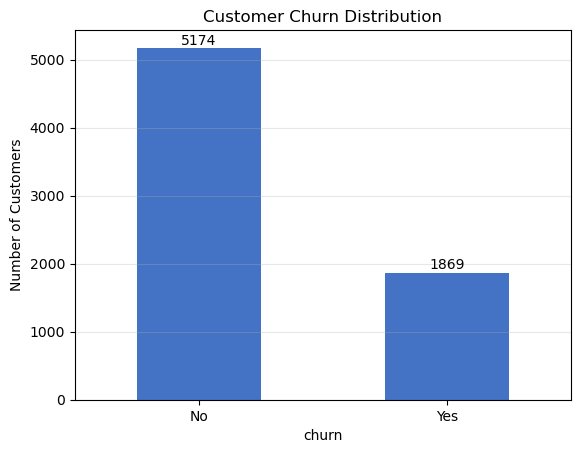

In [67]:
import matplotlib.pyplot as plt
ax = df['churn'].value_counts().plot(
    kind='bar',
    color='#4472C4'
)

plt.title('Customer Churn Distribution')
plt.xlabel('churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(df['churn'].value_counts()):
    ax.text(i, value + 50, str(value), ha='center')

plt.show()

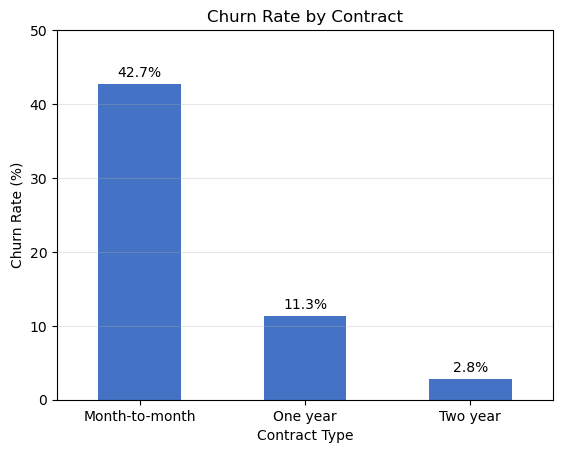

In [68]:
churn_contract = pd.crosstab(
    df['contract_type'],
    df['churn'],
    normalize='index'
) * 100

ax = churn_contract['Yes'].plot(
    kind='bar',
    color='#4472C4'
)

plt.title('Churn Rate by Contract')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(churn_contract['Yes']):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.show()

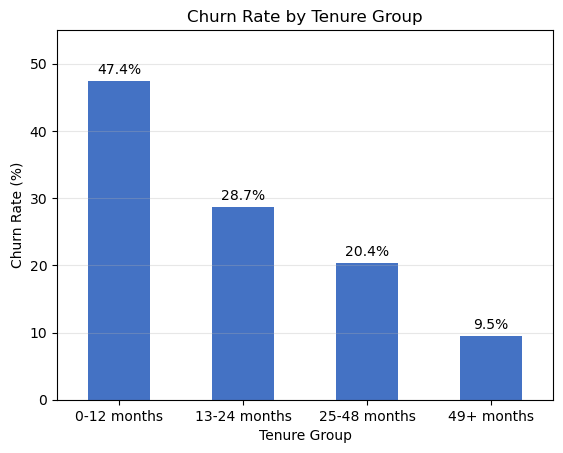

In [69]:
churn_tenure = pd.crosstab(
    df['tenure_group'],
    df['churn'],
    normalize='index'
) * 100

ax = churn_tenure['Yes'].plot(
    kind='bar',
    color='#4472C4'
)

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 55)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(churn_tenure['Yes']):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.show()

### Churn Rate by Internet Service

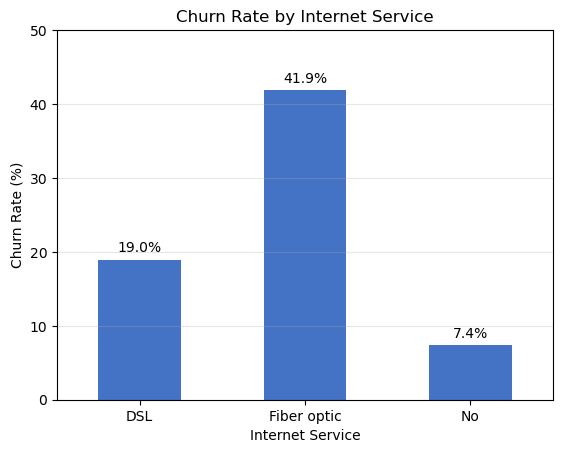

In [70]:
churn_internet = pd.crosstab(
    df['internet_service'],
    df['churn'],
    normalize='index'
) * 100

ax = churn_internet['Yes'].plot(
    kind='bar',
    color='#4472C4'
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(churn_internet['Yes']):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.show()

### Churn Rate by Payment Method

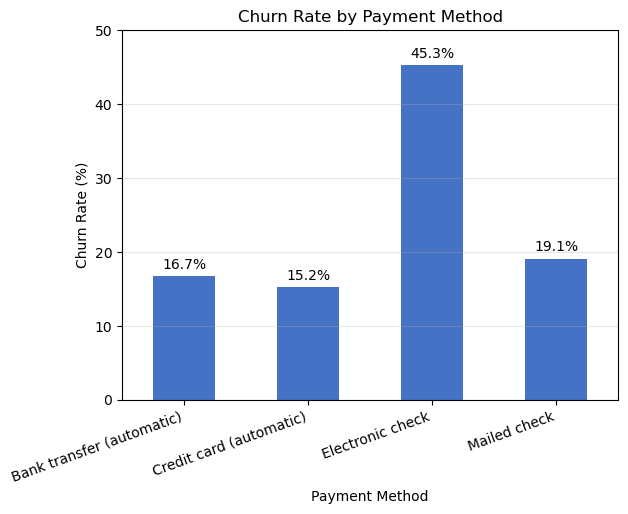

In [71]:
churn_payment = pd.crosstab(
    df['payment_method'],
    df['churn'],
    normalize='index'
) * 100

ax = churn_payment['Yes'].plot(
    kind='bar',
    color='#4472C4'
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 50)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(churn_payment['Yes']):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.show()

### Average Monthly Charges by Churn

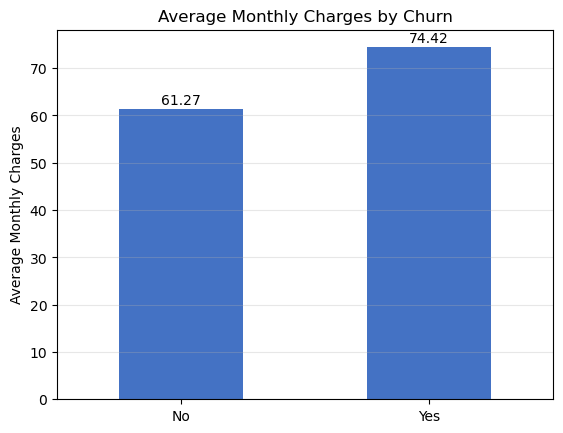

In [72]:
monthly_charges = df.groupby('churn')['monthly_charges'].mean()

ax = monthly_charges.plot(
    kind='bar',
    color='#4472C4'
)

plt.title('Average Monthly Charges by Churn')
plt.xlabel('')
plt.ylabel('Average Monthly Charges')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(monthly_charges):
    ax.text(i, value + 1, f'{value:.2f}', ha='center')

plt.show()

### Monthly Charges Distribution by Churn

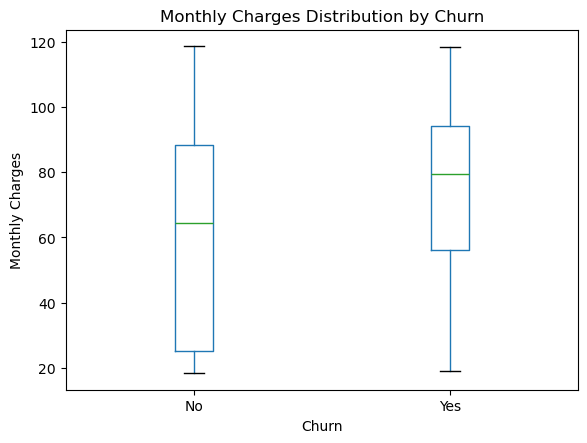

In [73]:
df.boxplot(
    column='monthly_charges',
    by='churn'
)

plt.title('Monthly Charges Distribution by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.grid(False)
plt.show()

### Churn by Senior Citizen Status

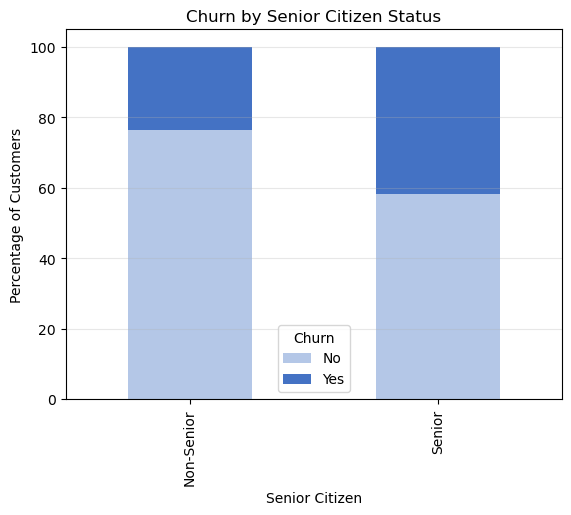

In [74]:
churn_senior = pd.crosstab(
    df['senior_citizen'],
    df['churn'],
    normalize='index'
) * 100

ax = churn_senior.plot(
    kind='bar',
    stacked=True,
    color=['#B4C7E7', '#4472C4']
)

plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage of Customers')
plt.xticks([0, 1], ['Non-Senior', 'Senior'])
plt.legend(title='Churn')
plt.grid(axis='y', alpha=0.3)

plt.show()

### Customer Distribution by Tech Support

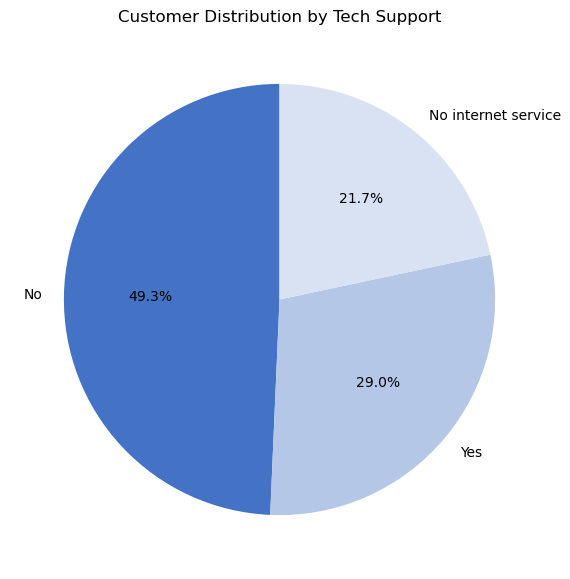

In [77]:
tech_support_count = df['tech_support'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    tech_support_count,
    labels=tech_support_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4472C4', '#B4C7E7', '#D9E2F3']
)

plt.title('Customer Distribution by Tech Support')
plt.show()

In [76]:
df.shape

(7043, 22)

In [79]:
df.to_csv('customer_churn_cleaned.csv', index=False)